In [1]:
import lbm_suite2p_python.postprocessing
import lbm_suite2p_python.utils
import lbm_suite2p_python.zplane
!uv pip install jupyterlab-vim

Using Python 3.11.12 environment at: C:\Users\RBO\repos\LBM-Suite2p-Python\.venv
Resolved 93 packages in 160ms
Installed 1 package in 24ms
 + jupyterlab-vim==4.1.4


# Suite2p Grid Search

Demonstrates parameter grid-search on `threshold_scaling` and `max_overlap` in suite2p.

These are [roi detection parameters](https://suite2p.readthedocs.io/en/latest/settings.html#roi-detection-settings). 

Can be easily extended to any parameters in the suite2p pipeline.

For an overview on these parameters and the impacts they have on segmentation results, see the [suite2p parameters guide]()

- `threshold_scaling` (default: 1.0): controls how much you want your neurons to "stand out" from the noise to count as a cell, lower will detect more cells.
- `max_overlap` (default: 0.75): set to 1 will allow all overlapping ROI's, 0.5 means if half of the cell is overlapping the roi will be discarded.

kbarber: mk301 2025-03-01

In [1]:
from pathlib import Path
import tifffile
import os
import matplotlib.pyplot as plt
import numpy as np
import suite2p
import mbo_utilities as mbo
import fastplotlib as fpl
import lbm_suite2p_python as lsp

Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x007\x08\x06\x00\x00\x00\xb6\x1bw\x99\x…

Valid,Device,Type,Backend,Driver
✅ (default),NVIDIA RTX A4000,DiscreteGPU,Vulkan,560.94
✅,NVIDIA RTX A4000,DiscreteGPU,D3D12,
✅,NVIDIA RTX A4000,DiscreteGPU,D3D12,
❗ limited,Microsoft Basic Render Driver,CPU,D3D12,
❌,NVIDIA RTX A4000/PCIe/SSE2,Unknown,OpenGL,4.6.0 NVIDIA 560.94


In [29]:
assembled_data_path = r"D:\W2_DATA\kbarber\2025_03_01\mk301\assembled"
files = mbo.get_files(assembled_data_path, "tif", 2)

In [30]:
files

['D:\\W2_DATA\\kbarber\\2025_03_01\\mk301\\assembled\\plane_01_mk301.tiff',
 'D:\\W2_DATA\\kbarber\\2025_03_01\\mk301\\assembled\\plane_02_mk301.tiff',
 'D:\\W2_DATA\\kbarber\\2025_03_01\\mk301\\assembled\\plane_03_mk301.tiff',
 'D:\\W2_DATA\\kbarber\\2025_03_01\\mk301\\assembled\\plane_04_mk301.tiff',
 'D:\\W2_DATA\\kbarber\\2025_03_01\\mk301\\assembled\\plane_05_mk301.tiff',
 'D:\\W2_DATA\\kbarber\\2025_03_01\\mk301\\assembled\\plane_06_mk301.tiff',
 'D:\\W2_DATA\\kbarber\\2025_03_01\\mk301\\assembled\\plane_07_mk301.tiff',
 'D:\\W2_DATA\\kbarber\\2025_03_01\\mk301\\assembled\\plane_08_mk301.tiff',
 'D:\\W2_DATA\\kbarber\\2025_03_01\\mk301\\assembled\\plane_09_mk301.tiff',
 'D:\\W2_DATA\\kbarber\\2025_03_01\\mk301\\assembled\\plane_10_mk301.tiff',
 'D:\\W2_DATA\\kbarber\\2025_03_01\\mk301\\assembled\\plane_11_mk301.tiff',
 'D:\\W2_DATA\\kbarber\\2025_03_01\\mk301\\assembled\\plane_12_mk301.tiff',
 'D:\\W2_DATA\\kbarber\\2025_03_01\\mk301\\assembled\\plane_13_mk301.tiff',
 'D:\\W2_DAT

In [16]:
input_tiff = files[6]
input_tiff

'D:\\W2_DATA\\kbarber\\2025_03_01\\mk301\\assembled\\plane_07_mk301.tiff'

In [21]:
metadata = mbo.get_metadata(input_tiff)
ops = suite2p.default_ops()
# set the framerate
base_ops = mbo.params_from_metadata(metadata, ops)
base_ops["anatomical_only"], base_ops["max_overlap"], base_ops["threshold_scaling"]

Ops provided. Setting pipeline to suite2p


(0, 0.75, 1.0)

In [22]:
save_path = Path(r"./grid_search")
save_path.mkdir(exist_ok=True)

In [27]:
base_ops["anatomical_only"] = 3
base_ops["diameter"] = 6
base_ops["flow_threshold"] = 0
base_ops["cellprob_threshold"] = -6  # default is 0, can be negative
base_ops["max_overlap"] = 1.0

# base_ops["sparse_mode"] = True
# base_ops["spatial_hp_cp"] = 0.5

# base_ops["tau"] = 0.15
# base_ops["flow_threshold"] = -6
# base_ops["pretrained_model"] = "cyto3"

search_dict = {
    "max_overlap": [0.6, 0.75, 1],
    "threshold_scaling": [0.75, 1, 1.25],
}
lbm_suite2p_python.run_lsp.run_grid_search(
    base_ops,
    search_dict,
    input_file=input_tiff,
    save_root=save_path.joinpath("spatial"),
)

Saving grid-search in grid_search\spatial
Running grid search in: grid_search\spatial\max0.60_thr0.75


NameError: name 'lsp' is not defined

In [134]:
out_path = save_path2.joinpath("registration")
groups = list(out_path.iterdir())

group_dict = {}
for path in groups:
    tifs = mbo.get_files(path, 'tif', 3)
    files = mbo.get_files(path, 'ops.npy', 4)
    ops = lbm_suite2p_python.postprocessing.load_ops(files[0])
    print(ops["fast_disk"])
    group_dict[path.name] = np.concatenate([tifffile.imread(tif) for tif in tifs])

# reg_files = mbo.get_files(out_path, '.tif')

c:\Users\RBO\repos\nb_sandbox\2025_04\lsp\grid\registration
c:\Users\RBO\repos\nb_sandbox\2025_04\lsp\grid\registration
c:\Users\RBO\repos\nb_sandbox\2025_04\lsp\grid\registration


In [ ]:
data[0].shape

(903, 448, 448)

In [106]:
iw = fpl.ImageWidget(data=[group_dict[key] for key, _ in group_dict.items()],)
iw.show()

In [ ]:
# data = np.load("../lsp/grid/registration/two0/plane0/data.bin")
nframes = metadata["num_frames"]
bin_size = int(max(1, nframes // ops["nbinned"], np.round(ops["tau"] * ops["fs"])))

In [27]:
ops_path = r"../lsp/grid/registration/two0/plane0/ops.npy"
ops = lbm_suite2p_python.postprocessing.load_ops(ops_path)
bin_path = r"../lsp/grid/registration/two0/plane0/data.bin"

In [ ]:
with suite2p.io.BinaryFile(filename=bin_path, Ly=ops["Ly"], Lx=ops["Lx"]) as f:
    mov = f.bin_movie(
        bin_size=bin_size,
        bad_frames=ops.get("badframes"),
        y_range=ops["yrange"],
        x_range=ops["xrange"],
    )

In [30]:
iw = fpl.ImageWidget(mov)
iw.show()

In [36]:
mov.shape[0] * 17

578

In [42]:
mbo.save_mp4("./out.mp4", images=mov, framerate=1, speedup=1, win=1, normalize=True)

Normalizing mp4 images to [0, 1]
Saving 34 frames to ./out.mp4
Video saved to ./out.mp4


In [44]:
ops_files = mbo.get_files("~/repos/nb_sandbox/2025_04/lsp/grid", "ops.npy", 6)
ops_files

['C:\\Users\\RBO\\repos\\nb_sandbox\\2025_04\\lsp\\grid\\high_pass\\hig125\\plane0\\ops.npy',
 'C:\\Users\\RBO\\repos\\nb_sandbox\\2025_04\\lsp\\grid\\high_pass\\hig75\\plane0\\ops.npy',
 'C:\\Users\\RBO\\repos\\nb_sandbox\\2025_04\\lsp\\grid\\spatial_hp\\spa20\\plane0\\ops.npy',
 'C:\\Users\\RBO\\repos\\nb_sandbox\\2025_04\\lsp\\grid\\spatial_hp\\spa25\\plane0\\ops.npy',
 'C:\\Users\\RBO\\repos\\nb_sandbox\\2025_04\\lsp\\grid\\spatial_hp\\spa30\\plane0\\ops.npy',
 'C:\\Users\\RBO\\repos\\nb_sandbox\\2025_04\\lsp\\grid\\tau\\tau0.75\\plane0\\ops.npy',
 'C:\\Users\\RBO\\repos\\nb_sandbox\\2025_04\\lsp\\grid\\tau\\tau1.25\\plane0\\ops.npy',
 'C:\\Users\\RBO\\repos\\nb_sandbox\\2025_04\\lsp\\grid\\tau\\tau1.75\\plane0\\ops.npy',
 'C:\\Users\\RBO\\repos\\nb_sandbox\\2025_04\\lsp\\grid\\thr_scale\\thr0.25\\plane0\\ops.npy',
 'C:\\Users\\RBO\\repos\\nb_sandbox\\2025_04\\lsp\\grid\\thr_scale\\thr0.75\\plane0\\ops.npy',
 'C:\\Users\\RBO\\repos\\nb_sandbox\\2025_04\\lsp\\grid\\thr_scale\\thr1.0

In [62]:
iscell = np.load(Path(ops["save_path"]).joinpath("iscell.npy"), allow_pickle=True).astype(bool)[:, 0]
stat = np.load(Path(ops["save_path"]).joinpath("stat.npy"), allow_pickle=True)

In [63]:
ops = lbm_suite2p_python.postprocessing.load_ops(ops_files[0])
fraw, fneu, spks = lsp.load_traces(ops)

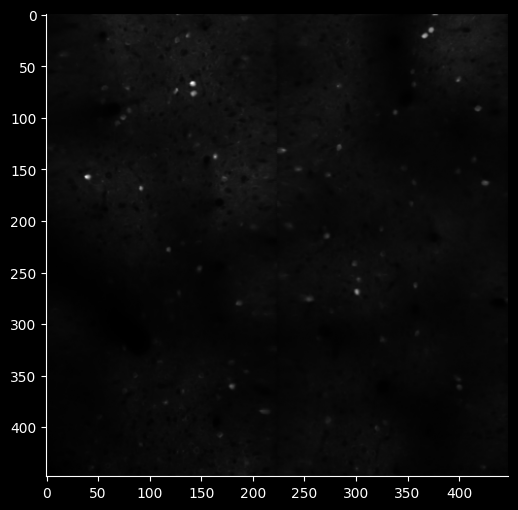

In [70]:
proj = "meanImg"
data = ops[proj]
mean_img = ops[proj]
shape = data.shape
fig, ax = plt.subplots(figsize=(6, 6), facecolor='black')
# vmin = np.nanpercentile(data, 2)
# vmax = np.nanpercentile(data, 98)
ax.imshow(data, cmap='gray')

In [71]:
# Get image size
Lx = ops["Lx"]
Ly = ops["Ly"]

# Get the cell ids
ncells = len(stat)
cell_ids = np.arange(ncells)  # assign each cell an ID, starting from 0.
cell_ids = cell_ids[iscell == 1]  # only take the ROIs that are actually cells.
num_rois = len(cell_ids)

# Generate ROI masks in a format usable by FISSA (in this case, a list of masks)
rois = [np.zeros((Ly, Lx), dtype=bool) for n in range(num_rois)]

for i, n in enumerate(cell_ids):
    # i is the position in cell_ids, and n is the actual cell number
    ypix = stat[n]["ypix"][~stat[n]["overlap"]]
    xpix = stat[n]["xpix"][~stat[n]["overlap"]]
    rois[i][ypix, xpix] = 1

In [72]:
ops = suite2p.default_ops()
print(f"Defaults: thr_scaling={ops['threshold_scaling']}, spatial_hp={ops['spatial_hp_detect']}")

Defaults: thr_scaling=1.0, spatial_hp=25


In [62]:
default_set_spa = lbm_suite2p_python.postprocessing.load_ops(ops_files[1])
default_set_thr = lbm_suite2p_python.postprocessing.load_ops(ops_files[5])
print(f"spa-def: thr_scaling={default_set_spa['threshold_scaling']}, spatial_hp={default_set_spa['spatial_hp_detect']}")
print(f"thr-def: thr_scaling={default_set_thr['threshold_scaling']}, spatial_hp={default_set_thr['spatial_hp_detect']}")

spa-def: thr_scaling=1.0, spatial_hp=25
thr-def: thr_scaling=1.0, spatial_hp=25


In [63]:
from suite2p import default_ops

default_keys = set(default_ops().keys())

same = {}
diff = {}

for k in default_keys:
    v1 = default_set_spa.get(k)
    v2 = default_set_thr.get(k)
    if isinstance(v1, (np.ndarray, list, dict)) or isinstance(v2, (np.ndarray, list, dict)):
        continue
    if v1 == v2:
        same[k] = v1
    else:
        diff[k] = (v1, v2)

print("Same:")
for k, v in same.items():
    print(f"  {k}: {v}")

print("\nDifferent:")
for k, (v1, v2) in diff.items():
    print(f"  {k}: spa={v1}, thr={v2}")


Same:
  nwb_series: 
  force_refImg: False
  nimg_init: 300
  min_neuropil_pixels: 350
  smooth_sigma_time: 0
  neucoeff: 0.7
  th_badframes: 1.0
  spatial_hp_cp: 0
  look_one_level_down: False
  force_sktiff: False
  preclassify: 0.0
  sig_baseline: 10.0
  pad_fft: False
  aspect: 1.0
  connected: True
  reg_tif_chan2: False
  save_mat: False
  spikedetect: True
  mesoscan: False
  baseline: maximin
  nchannels: 1
  fs: 10.0
  subpixel: 10
  smooth_sigma: 1.15
  bidiphase: 0
  nonrigid: True
  cellprob_threshold: 0.0
  max_iterations: 20
  spatial_scale: 0
  suite2p_version: 0.1.dev2336+g51d90dd
  bidi_corrected: False
  allow_overlap: False
  frames_include: -1
  denoise: False
  threshold_scaling: 1.0
  delete_bin: False
  keep_movie_raw: False
  do_registration: True
  spatial_taper: 40
  win_baseline: 60.0
  reg_tif: False
  prctile_baseline: 8.0
  lam_percentile: 50.0
  soma_crop: True
  max_overlap: 0.75
  classifier_path: 
  align_by_chan: 1
  save_NWB: False
  pretrained_model

In [51]:
default_set_thr

{'suite2p_version': '0.1.dev2336+g51d90dd',
 'look_one_level_down': False,
 'fast_disk': 'c:\\Users\\RBO\\repos\\nb_sandbox\\2025_04\\lsp\\grid\\thr_scale',
 'delete_bin': False,
 'mesoscan': False,
 'bruker': False,
 'bruker_bidirectional': False,
 'h5py': [],
 'h5py_key': 'data',
 'nwb_file': '',
 'nwb_driver': '',
 'nwb_series': '',
 'save_path0': 'c:\\Users\\RBO\\repos\\nb_sandbox\\2025_04\\lsp\\grid\\thr_scale',
 'save_folder': 'thr1.00',
 'subfolders': [],
 'move_bin': False,
 'nplanes': 1,
 'nchannels': 1,
 'functional_chan': 1,
 'tau': 1.0,
 'fs': 10.0,
 'force_sktiff': False,
 'frames_include': -1,
 'multiplane_parallel': False,
 'ignore_flyback': [],
 'preclassify': 0.0,
 'save_mat': False,
 'save_NWB': False,
 'combined': True,
 'aspect': 1.0,
 'do_bidiphase': False,
 'bidiphase': 0,
 'bidi_corrected': False,
 'do_registration': True,
 'two_step_registration': False,
 'keep_movie_raw': False,
 'nimg_init': 300,
 'batch_size': 500,
 'maxregshift': 0.1,
 'align_by_chan': 1,
 '

In [50]:
same = {k: default_set_spa[k] for k in default_set_spa if k in default_set_thr and default_set_spa[k] == default_set_thr[k]}
diff = {k: (default_set_spa[k], default_set_thr[k]) for k in default_set_spa if k in default_set_thr and default_set_spa[k] != default_set_thr[k]}

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:
print("Same values:")
for k, v in same.items():
    print(f"  {k}: {v}")

print("\nDifferent values:")
for k, (v1, v2) in diff.items():
    print(f"  {k}: spa={v1}, thr={v2}")


In [52]:
from suite2p.io import tiff_to_binary

# help(tiff_to_binary)

ops = suite2p.default_ops()
metadata = mbo.get_metadata("./data/plane_01.tif")

ops["data_path"] = Path("./data").resolve()
ops["tiff_list"] = ["plane_01.tif"]
ops["save_path"] = Path("./data").resolve()
ops["save_path0"] = ops["save_path"]
ops["save_folder"] = "test"

In [62]:
from suite2p.io import tiff
from suite2p import default_ops

ops = default_ops()
ops['data_path'] = ['./data']
ops['save_path0'] = './data'
ops['tiff_list'] = ["plane_07.tif"]
ops['save_folder'] = 'suite2p'
ops['nplanes'] = 1
ops['nchannels'] = 1
ops['functional_chan'] = 1
ops['fast_disk'] = './data'

ops = tiff.tiff_to_binary(ops)

tif
** Found 1 tifs - converting to binary **


In [72]:
from suite2p.io.binary import BinaryFile
from suite2p.registration import register

10

In [77]:
refImg = register.pick_initial_reference(mov)

In [65]:
help(tiff_to_binary)

Help on function tiff_to_binary in module suite2p.io.tiff:

tiff_to_binary(ops)
    finds tiff files and writes them to binaries

    Parameters
    ----------
    ops : dictionary
        "nplanes", "data_path", "save_path", "save_folder", "fast_disk", "nchannels", "keep_movie_raw", "look_one_level_down"

    Returns
    -------
        ops : dictionary of first plane
            ops["reg_file"] or ops["raw_file"] is created binary
            assigns keys "Ly", "Lx", "tiffreader", "first_tiffs",
            "frames_per_folder", "nframes", "meanImg", "meanImg_chan2"



In [117]:
for i in range(len(input_files)):
    if i in [1]:
        plane_savepath = save_path.joinpath(f"plane_0{i}")
        plane_savepath.mkdir(exist_ok=True)
        print(plane_savepath)
        # output_ops = lsp.run_plane(ops, input_files[i], save_path, replot=True, dryrun=True)

c:\Users\RBO\repos\nb_sandbox\2025_04\lsp\defaults\plane_01


In [96]:
plane_savepath.parent

WindowsPath('c:/Users/RBO/repos/nb_sandbox/2025_04/lsp/defaults')

In [110]:
ops_files = mbo.get_files(plane_savepath.parent, 'ops.npy', 4)
seg_files = mbo.get_files(plane_savepath.parent, 'segmentation.png', 4)
ops_files[1:5]

['C:\\Users\\RBO\\repos\\nb_sandbox\\2025_04\\lsp\\defaults\\plane_01_ts0.00_shp5_mo0.25_hp80\\plane_07\\plane0\\ops.npy',
 'C:\\Users\\RBO\\repos\\nb_sandbox\\2025_04\\lsp\\defaults\\plane_02_ts0.00_shp5_mo0.25_hp150\\plane_07\\plane0\\ops.npy',
 'C:\\Users\\RBO\\repos\\nb_sandbox\\2025_04\\lsp\\defaults\\plane_03_ts0.00_shp5_mo0.62_hp10\\plane_07\\plane0\\ops.npy',
 'C:\\Users\\RBO\\repos\\nb_sandbox\\2025_04\\lsp\\defaults\\plane_04_ts0.00_shp5_mo0.62_hp80\\plane_07\\plane0\\ops.npy']

In [116]:
EXCLUDE_KEYS = {
    'suite2p_version', 'save_path0', 'save_folder', 'fast_disk',
    'subfolders', 'nwb_file', 'nwb_driver', 'nwb_series',
    'move_bin', 'delete_bin', 'look_one_level_down', 'fs', 'ops_file', 'keep_movie_raw'
}

# Find all ops files
ops_files = mbo.get_files(plane_savepath.parent, 'ops.npy', 4)
default = suite2p.default_ops()

rows = []
for fpath in ops_files:
    op = lbm_suite2p_python.postprocessing.load_ops(fpath)
    diff = {
        k: v for k, v in op.items()
        if k not in EXCLUDE_KEYS and k in default and v != default[k]
    }
    # diff['ops_file'] = str(fpath)
    rows.append(diff)

df = pd.DataFrame(rows)
df

,tau,threshold_scaling,max_overlap,high_pass,spatial_hp_detect
0,1.5,0.00,0.250,10.0,5.0
1,1.5,0.00,0.250,80.0,5.0
2,1.5,0.00,0.250,150.0,5.0
3,1.5,0.00,0.625,10.0,5.0
4,1.5,0.00,0.625,80.0,5.0
...,...,...,...,...,...
77,1.5,0.75,0.625,80.0,45.0
78,1.5,0.75,0.625,150.0,45.0
79,1.5,0.75,1.000,10.0,45.0
80,1.5,0.75,1.000,80.0,45.0


In [33]:
import tifffile
data = tifffile.memmap(in_file)
data.shape

(903, 448, 448)

In [ ]:
mbo.run_gui(data)

Data provided and set.
Is running jupyter
